In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#NB distance
def d1(x, y):
    num = 0.5*(abs(x - y) * (abs(x) + abs(y)))
    den = x*x + y*y
    return 0.0 if den == 0 else (num / den)

def Delta(x, y, z):
    return d1(x, z) - d1(x, y) - d1(y, z)

In [ ]:
#FIGURE 1

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


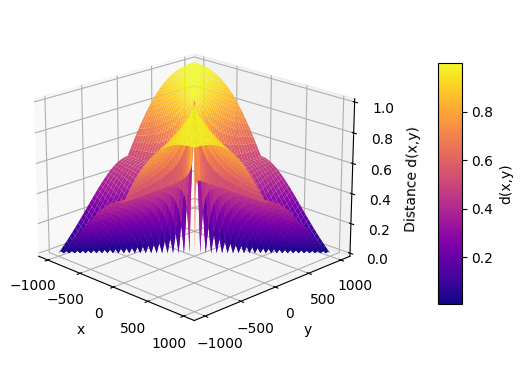

In [ ]:
# d(x,y) surface
L = 1000
grid = 250  
xs = np.linspace(-L, L, grid)
ys = np.linspace(-L, L, grid)
X, Y = np.meshgrid(xs, ys)

D = np.vectorize(d1)(X, Y)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, D, linewidth=0, antialiased=True, cmap='plasma')

fig.colorbar(surf, ax=ax, shrink=0.65, aspect=10, pad=0.15, label="d(x,y)")
#fig.colorbar(surf, ax=ax, shrink=0.65, label="d(x,y)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Distance d(x,y)")
ax.view_init(elev=20, azim=-45)
#plt.title("Distance between x and y under the proposed metric")


plt.savefig("figure1.png", dpi=300, bbox_inches="tight")
plt.savefig("figure1.tiff", dpi=300, bbox_inches="tight")
plt.savefig('figure1.eps', format='eps',bbox_inches="tight")


plt.show()

In [ ]:
#FIGURE 2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


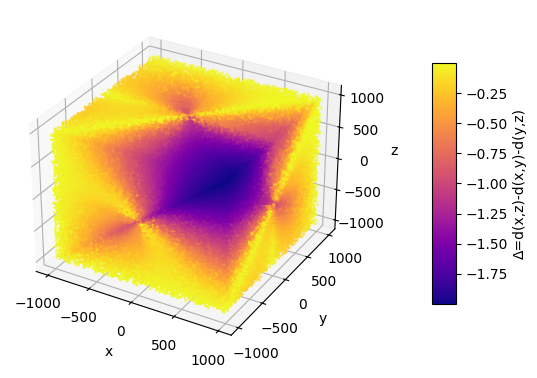

min Δ: -1.999963575976031  max Δ: -4.817464349258973e-09
count(Δ < 0): 250000


In [ ]:
# 4D plot of triangle inequality (x,y,z in 3D; color=Delta)
L = 1000
M = 250_000 
rng = np.random.default_rng(23)

x = rng.uniform(-L, L, size=M)
y = rng.uniform(-L, L, size=M)
z = rng.uniform(-L, L, size=M)

dxy = np.vectorize(d1)(x, y)
dyz = np.vectorize(d1)(y, z)
dxz = np.vectorize(d1)(x, z)
delta = dxz - dxy - dyz

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(x, y, z, c=delta, s=1,cmap='plasma')  # s: nokta boyutu
fig.colorbar(sc, ax=ax, shrink=0.65, aspect=10, pad=0.15, label="Δ=d(x,z)-d(x,y)-d(y,z)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
#plt.title("Triangle inequality diagnostic (color = Δ)")

plt.savefig("figure2.png", dpi=300,bbox_inches="tight")
plt.savefig("figure2.tiff", dpi=300,bbox_inches="tight")
plt.savefig('figure2.eps', format='eps',bbox_inches="tight")

plt.show()

print("min Δ:", delta.min(), " max Δ:", delta.max())
print("count(Δ < 0):", np.sum(delta < 0))

In [ ]:
#FIGURE 3

min Δ: -1.999963575976031 max Δ: -4.817464349258973e-09
kept points: 8181 / 250000


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


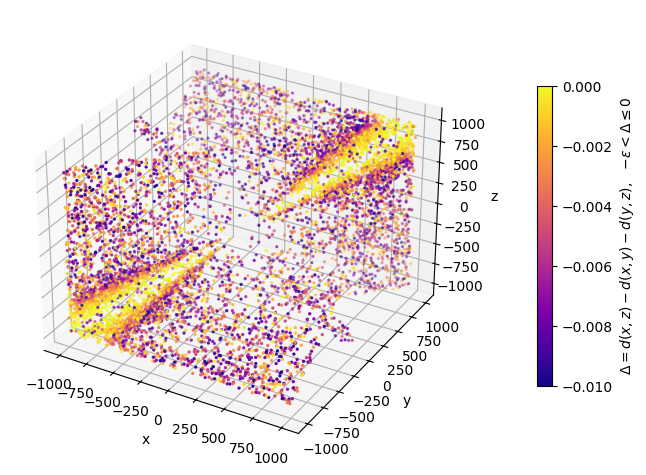

In [ ]:
#Near-zero region
import numpy as np
import matplotlib.pyplot as plt

# --- Delta definiton ---#
delta = dxz - dxy - dyz   # Δ = d(x,z) - d(x,y) - d(y,z)

# --- near-zero bölgeregion: -eps < Δ <= 0 ---
eps = 0.01
mask = (delta > -eps) & (delta <= 0)

print("min Δ:", float(np.min(delta)), "max Δ:", float(np.max(delta)))
print("kept points:", int(np.sum(mask)), "/", len(delta))

if np.sum(mask) == 0:
    print("Need larger eps value.")
else:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(
        np.asarray(x)[mask],
        np.asarray(y)[mask],
        np.asarray(z)[mask],
        c=np.asarray(delta)[mask],
        s=2,
        cmap="plasma",
        vmin=-eps,
        vmax=0
    )

    cbar = fig.colorbar(sc, ax=ax, shrink=0.65, pad=0.12)
    cbar.set_label(r'$\Delta = d(x,z)-d(x,y)-d(y,z)$,   $-\varepsilon < \Delta \leq 0$')

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
   # plt.title(rf"Near-zero region of triangle inequality residual ($\varepsilon={eps}$)")

    plt.savefig("figure3.png", dpi=300, bbox_inches="tight")
    plt.savefig("figure3.tiff", dpi=300, bbox_inches="tight")
    plt.savefig("figure3.eps", format="eps", bbox_inches="tight")

    plt.show()

In [ ]:
#FIGURE 4

In [6]:
#contuar 
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#NB distance
def NB_distance(x, y):
    numerator = np.sum(np.abs(x - y) * (np.abs(x) + np.abs(y)))
    denominator = np.sum(x**2 + y**2)
    return (numerator / denominator)*(0.5) if denominator != 0 else 0

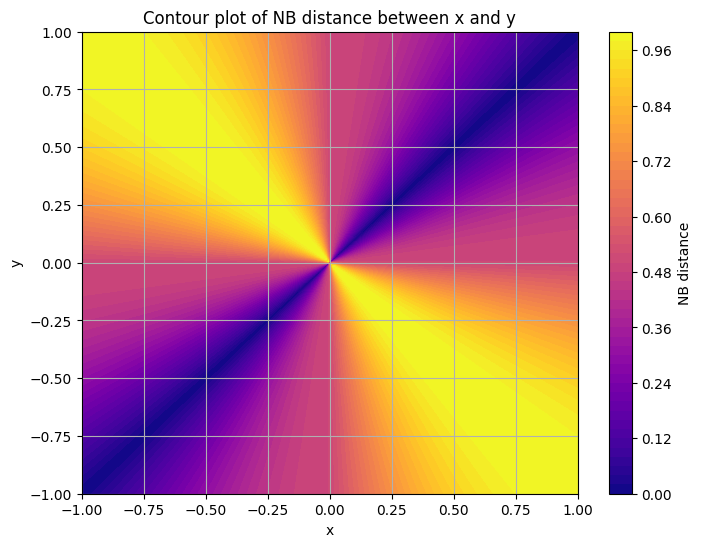

In [9]:
# Create grid
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)

# Compute distance
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = NB_distance(X[i, j], Y[i, j])

# Plot contour with filled levels
plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, Z, levels=50, cmap="plasma")
cbar = plt.colorbar(cp)
cbar.set_label("NB distance")
plt.title("Contour plot of NB distance between x and y")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)


plt.savefig("figure4.tiff", dpi=300)
plt.savefig('figure4.eps', format='eps')
plt.savefig('figure4.png', format='png')

plt.show()
